In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:

df = pd.read_csv('cleaned_loans.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (31522, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
1,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
2,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
3,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
4,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2


In [3]:
## 2. Feature: `risk_tier` (from loan_grade)
df['risk_tier'] = df['loan_grade'].apply(lambda g: 'Low Risk (A-C)' if g in ['A','B','C'] else 'High Risk (D-G)')

df.groupby('risk_tier')['loan_status'].agg(['mean','count']).rename(columns={'mean':'default_rate'})

,default_rate,count
risk_tier,,
High Risk (D-G),0.609583,4800
Low Risk (A-C),0.145236,26722


In [4]:
## 3. Feature: `dti_bucket` (Debt-to-Income Ratio Buckets)
def dti_bucket(pct):
    if pct < 0.10:
        return 'Low (<10%)'
    elif pct < 0.20:
        return 'Moderate (10-20%)'
    elif pct < 0.35:
        return 'High (20-35%)'
    else:
        return 'Very High (35%+)'

df['dti_bucket'] = df['loan_percent_income'].apply(dti_bucket)

order = ['Low (<10%)', 'Moderate (10-20%)', 'High (20-35%)', 'Very High (35%+)']
dti_summary = df.groupby('dti_bucket')['loan_status'].agg(['mean','count']).reindex(order)
dti_summary.columns = ['default_rate', 'num_loans']
dti_summary['default_rate'] = (dti_summary['default_rate']*100).round(2)
dti_summary

,default_rate,num_loans
dti_bucket,,
Low (<10%),11.52,8679
Moderate (10-20%),14.44,12149
High (20-35%),28.74,8380
Very High (35%+),71.09,2314


In [5]:
## 4. Feature: `is_renter_or_other` (Home Ownership Risk Flag)
df['is_renter_or_other'] = df['person_home_ownership'].isin(['RENT', 'OTHER'])

df.groupby('is_renter_or_other')['loan_status'].agg(['mean','count']).rename(columns={'mean':'default_rate'})

,default_rate,count
is_renter_or_other,,
False,0.116361,15409
True,0.311177,16113


In [6]:
## 5. Feature: `credit_history_bucket`
def hist_bucket(years):
    if years <= 3:
        return 'New (0-3 yrs)'
    elif years <= 7:
        return 'Established (4-7 yrs)'
    elif years <= 15:
        return 'Mature (8-15 yrs)'
    else:
        return 'Long-standing (15+ yrs)'

df['credit_history_bucket'] = df['cb_person_cred_hist_length'].apply(hist_bucket)

order = ['New (0-3 yrs)', 'Established (4-7 yrs)', 'Mature (8-15 yrs)', 'Long-standing (15+ yrs)']
hist_summary = df.groupby('credit_history_bucket')['loan_status'].agg(['mean','count']).reindex(order)
hist_summary.columns = ['default_rate', 'num_loans']
hist_summary['default_rate'] = (hist_summary['default_rate']*100).round(2)
hist_summary

,default_rate,num_loans
credit_history_bucket,,
New (0-3 yrs),22.75,11488
Established (4-7 yrs),21.23,11196
Mature (8-15 yrs),20.45,7726
Long-standing (15+ yrs),21.31,1112


In [7]:
## 6. Feature: `high_risk_intent`
df['high_risk_intent'] = df['loan_intent'].isin(['DEBTCONSOLIDATION', 'MEDICAL'])

df.groupby('high_risk_intent')['loan_status'].agg(['mean','count']).rename(columns={'mean':'default_rate'})

,default_rate,count
high_risk_intent,,
False,0.184919,20609
True,0.274535,10913


In [8]:
## 7. Feature: `income_bracket` (for dashboard segmentation, not derived from a default-rate cutpoint)
def income_bracket(income):
    if income < 30000:
        return 'Under $30K'
    elif income < 60000:
        return '$30K-$60K'
    elif income < 100000:
        return '$60K-$100K'
    else:
        return '$100K+'

df['income_bracket'] = df['person_income'].apply(income_bracket)

order = ['Under $30K', '$30K-$60K', '$60K-$100K', '$100K+']
income_summary = df.groupby('income_bracket')['loan_status'].agg(['mean','count']).reindex(order)
income_summary.columns = ['default_rate', 'num_loans']
income_summary['default_rate'] = (income_summary['default_rate']*100).round(2)
income_summary

,default_rate,num_loans
income_bracket,,
Under $30K,46.54,3335
$30K-$60K,25.87,13554
$60K-$100K,13.27,10126
$100K+,8.99,4507


In [9]:
## 8. Composite Feature: `risk_score`
df['risk_score'] = (
    (df['risk_tier'] == 'High Risk (D-G)').astype(int) +
    (df['cb_person_default_on_file'] == 'Y').astype(int) +
    (df['loan_percent_income'] >= 0.20).astype(int) +
    (df['is_renter_or_other']).astype(int)
)

df['risk_score'].value_counts().sort_index()

risk_score
0     8720
1    12178
2     7500
3     2453
4      671
Name: count, dtype: int64

,default_rate,num_loans
risk_score,,
0,5.00,8720
1,10.41,12178
2,40.47,7500
3,61.35,2453
4,83.90,671


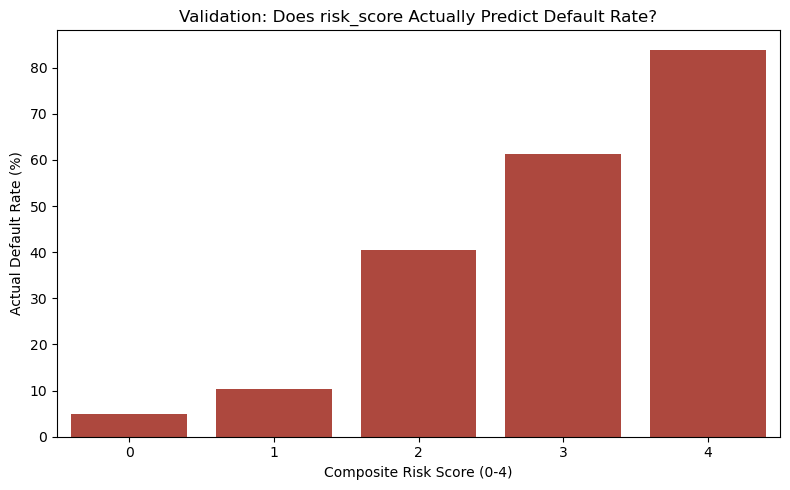

In [10]:
## 9. Validate the Composite Risk Score
risk_validation = df.groupby('risk_score')['loan_status'].agg(['mean','count'])
risk_validation.columns = ['default_rate', 'num_loans']
risk_validation['default_rate'] = (risk_validation['default_rate']*100).round(2)
display(risk_validation)

fig, ax = plt.subplots(figsize=(8,5))
sns.barplot(x=risk_validation.index, y='default_rate', data=risk_validation, color='#C0392B', ax=ax)
ax.set_xlabel('Composite Risk Score (0-4)')
ax.set_ylabel('Actual Default Rate (%)')
ax.set_title('Validation: Does risk_score Actually Predict Default Rate?')
plt.tight_layout()
plt.savefig('risk_score_validation.png', dpi=120)
plt.show()

In [11]:
## 10. Final Feature Set Overview
new_features = ['risk_tier', 'dti_bucket', 'is_renter_or_other', 'credit_history_bucket',
                 'high_risk_intent', 'income_bracket', 'risk_score']

print("Engineered features added:")
for f in new_features:
    print(f"  - {f}")

print(f"\nFinal shape: {df.shape}")
df[new_features].head()

Engineered features added:
  - risk_tier
  - dti_bucket
  - is_renter_or_other
  - credit_history_bucket
  - high_risk_intent
  - income_bracket
  - risk_score

Final shape: (31522, 19)


,risk_tier,dti_bucket,is_renter_or_other,credit_history_bucket,high_risk_intent,income_bracket,risk_score
0,Low Risk (A-C),Moderate (10-20%),False,New (0-3 yrs),False,Under $30K,0
1,Low Risk (A-C),Very High (35%+),False,New (0-3 yrs),True,Under $30K,1
2,Low Risk (A-C),Very High (35%+),True,New (0-3 yrs),True,$60K-$100K,2
3,Low Risk (A-C),Very High (35%+),True,Established (4-7 yrs),True,$30K-$60K,3
4,Low Risk (A-C),High (20-35%),False,New (0-3 yrs),False,Under $30K,1


In [14]:
## 11. Export Feature-Engineered Dataset

df.to_csv('loans_features.csv', index=False)

In [18]:
pip install psycopg2-binary

Note: you may need to restart the kernel to use updated packages.


In [19]:
# Connect to PostgreSQL
# Replace placeholders with your actual details
from sqlalchemy import create_engine, text
username = "postgres"        # default user
password = "123456780"   # the password you set during installation
host = "localhost"           # if running locally
port = "5432"                 # default PostgreSQL port
database = "credit_risk_db"   # the database you created in pgAdmin

engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")

# Step 2: Load DataFrame into PostgreSQL
table_name = "loans"   # single table containing all cleaned + engineered columns
df.to_sql(table_name, engine, if_exists="replace", index=False)

print(f"Data successfully loaded into table '{table_name}' in database '{database}'.")

Data successfully loaded into table 'loans' in database 'credit_risk_db'.


In [20]:
from sqlalchemy import text

with engine.connect() as conn:
    count = conn.execute(text(f"SELECT COUNT(*) FROM {table_name}")).scalar()
    print(f"Rows in '{table_name}' table: {count}")

Rows in 'loans' table: 31522
